In [6]:
# python
import sys
import os
import importlib
# columnar analysis
import awkward as ak
from coffea import processor, nanoevents
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import llpnanoaodschema, sidm_processor,  utilities 
from sidm.studies.cosmicVeto import functions
# always reload local modules to pick up changes during development
importlib.reload(llpnanoaodschema)
importlib.reload(sidm_processor)

<module 'sidm.tools.sidm_processor' from '/uscms_data/d3/mjose/SIDM/sidm/tools/sidm_processor.py'>

In [7]:
data = functions.get_data_files()
data =  [x for x in data if "C" in x]
DY = functions.get_bg_file_names("DYJetsToLL")
print(DY)

['DYJetsToLL_M10to50', 'DYJetsToLL_M50']


In [8]:
fileset = utilities.make_fileset([DY[1]], "skimmed_llpNanoAOD_v2", location_cfg="backgrounds.yaml", max_files=1,replace_xcache=True, )
file  =  fileset[DY[1]]["files"][0]

In [44]:
print (file)root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/DYJetsToLL_M50_LLPnanoAODv1/skimmed_output_1.root

root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/Skims/DYJetsToLL_M50_LLPnanoAODv1/skimmed_output_1.root


In [9]:
events = nanoevents.NanoEventsFactory.from_root(
    {file: "Events"},
    schemaclass=llpnanoaodschema.LLPNanoAODSchema,
).events()



['dxy',
 'dxyErr',
 'dxybs',
 'dz',
 'dzErr',
 'eta',
 'ip3d',
 'jetPtRelv2',
 'jetRelIso',
 'mass',
 'miniPFRelIso_all',
 'miniPFRelIso_chg',
 'pfRelIso03_all',
 'pfRelIso03_chg',
 'pfRelIso04_all',
 'phi',
 'pt',
 'ptErr',
 'segmentComp',
 'sip3d',
 'softMva',
 'tkRelIso',
 'tunepRelPt',
 'mvaLowPt',
 'mvaTTH',
 'charge',
 'jetIdx',
 'nStations',
 'nTrackerLayers',
 'pdgId',
 'tightCharge',
 'fsrPhotonIdx',
 'highPtId',
 'highPurity',
 'inTimeMuon',
 'isGlobal',
 'isPFcand',
 'isStandalone',
 'isTracker',
 'jetNDauCharged',
 'looseId',
 'mediumId',
 'mediumPromptId',
 'miniIsoId',
 'multiIsoId',
 'mvaId',
 'mvaLowPtId',
 'pfIsoId',
 'puppiIsoId',
 'softId',
 'softMvaId',
 'tightId',
 'tkIsoId',
 'triggerIdLoose',
 'idx',
 'trkPt',
 'trkPtErr',
 'dzPV',
 'dzPVErr',
 'dxyPVTraj',
 'dxyPVTrajErr',
 'dxyPVSigned',
 'dxyPVSignedErr',
 'ip3DPVSigned',
 'ip3DPVSignedErr',
 'dxyBS',
 'dxyBSErr',
 'dzBS',
 'dzBSErr',
 'dxyBSTraj',
 'dxyBSTrajErr',
 'dxyBSSigned',
 'dxyBSSignedErr',
 'ip3DBSSi


Event 0
                             pT                  eta                  phi            diMuon pt                  DTH                  CSC                   0                   -1                   -2                   -3
Reco               [31.1, 21.2]         [1.21, 1.06]    [0.0063, -0.0543]           52.240005              [0, 0]             [18, 0]
Gen         [31.6, 25.8, 0.166]  [1.21, 2.66, -2.51] [0.00654, 3.09, -0.357]                 None                None                None      [13, -13, -13]       [13, -13, 411]       [13, -13, 413]         [23, 23, 14]

Event 1
                             pT                  eta                  phi            diMuon pt                  DTH                  CSC                   0                   -1                   -2
Reco               [37.1, 34.7]       [-1.32, -1.31]     [-0.987, -0.965]           71.793915              [0, 0]             [0, 17]
Gen                [40.5, 35.1]       [-2.55, -1.31]       [2.42, -0.965] 

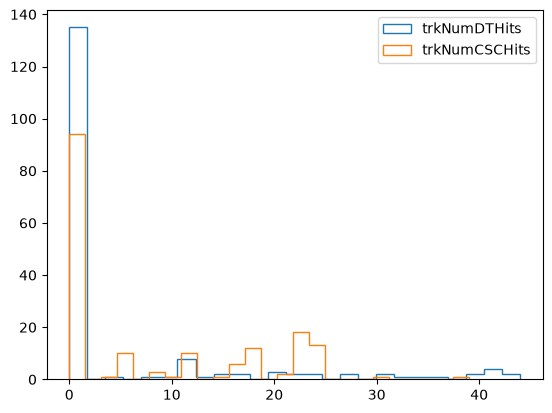

In [72]:
muon = events.Muon[
    ak.argsort(events.Muon.pt, axis=1, ascending=False)
]
has_two_muons = ak.num(muon) >= 2
events_2mu = events[has_two_muons]
muon_2mu = muon[has_two_muons]
muon0 = muon_2mu[:, 0]  # leading pT
muon1 = muon_2mu[:, 1]  # subleading pT
diMu_pt = (muon0 + muon1).pt
deltaR = muon0.delta_r(muon1)
mask = (deltaR < 0.5) #& (diMu_pt>400)
events_selected = events_2mu[mask]
muon_selected = muon_2mu[mask]

genpart = events_selected.GenPart
# genpart_idx = ak.local_index(genpart, axis=1)
gen_muon_mask = (
    (abs(genpart.pdgId) == 13) &
    (genpart.status == 1) 
)

gen_muons = genpart[gen_muon_mask]
# gen_muon_indices = genpart_idx[gen_muon_mask]
sort_idx = ak.argsort(
    gen_muons.pt,
    axis=1,
    ascending=False
)

gen_muons = gen_muons[sort_idx]
dimuon_pt = (muon_selected[:,0] + muon_selected[:,1]).pt
# gen_dimuon_pt = (gen_muons[:,0] + gen_muons[:,1]).pt
# gen_muon_indices = gen_muon_indices[sort_idx]
for x in range(5):
    print(f"\nEvent {x}")
    mother_idx = gen_muons[x].genPartIdxMother
    mother_pdgid = genpart[x].pdgId[mother_idx]

    pdg_gen = {}
    count = 0
    muons = gen_muons[x]
    muons_pdgId = [int(i.pdgId) for i in muons]
    pdg_gen[count] = muons_pdgId
    idx = [int(i) for i in muons.genPartIdxMother]
    while any(abs(pdgid) == 13 for pdgid in muons_pdgId):
        count += 1
        mother_pdgId = [
            int(genpart[x].pdgId[i])
            for i in idx
        ]
        pdg_gen[count] = mother_pdgId
        # Move to the next generation
        idx = [
            int(genpart[x].genPartIdxMother[i])
            for i in idx
            if i >= 0
        ]
        muons_pdgId = mother_pdgId
    n_gen = pdg_gen.keys()
    


    
    print(f"{'':10s} {'pT':>20s} {'eta':>20s} {'phi':>20s} {'diMuon pt':>20s} {'DTH':>20s} {'CSC':>20s}"  + " ".join(f"{str(-h):>20s}" for h in n_gen))

    print(
        f"{'Reco':10s} "
        f"{str(muon_selected[x].pt):>20s} "
        f"{str(muon_selected[x].eta):>20s} "
        f"{str(muon_selected[x].phi):>20s}"
         f"{str(dimuon_pt[x]):>20s}"
         f"{str(muon_selected[x].trkNumDTHits):>20s}"
        f"{str(muon_selected[x].trkNumCSCHits):>20s}"
    )

    print(
    f"{'Gen':10s} "
    f"{str(gen_muons[x].pt):>20s} "
    f"{str(gen_muons[x].eta):>20s} "
    f"{str(gen_muons[x].phi):>20s} "
    f"{str(None):>20s}"
    f"{str(None):>20s}"
        f"{str(None):>20s}"
    + " ".join(f"{str(pdg_gen[k]):>20s}" for k in pdg_gen)
)
plt.hist(ak.to_numpy(ak.flatten(muon_selected.trkNumDTHits)), bins =25, label = "trkNumDTHits", histtype = "step")

plt.hist(ak.to_numpy(ak.flatten(muon_selected.trkNumCSCHits)), bins =25, label = "trkNumCSCHits", histtype = "step")
plt.legend()
    

(array([24., 25.,  8.,  2.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([  8.34012413,  81.71011353, 155.08009338, 228.45007324,
        301.82006836, 375.19006348, 448.56002808, 521.93005371,
        595.30004883, 668.67004395, 742.04003906]),
 <BarContainer object of 10 artists>)

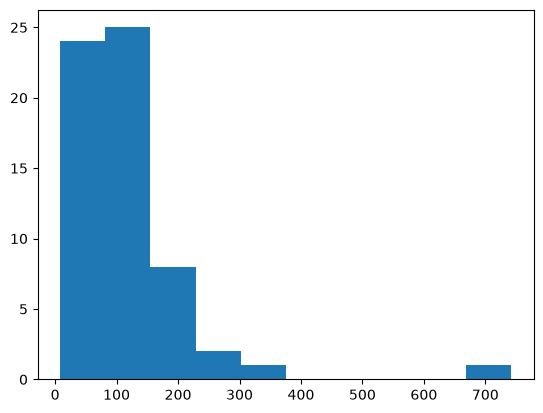

In [46]:
import matplotlib.pyplot as plt
plt.hist(dimuon_pt, bins =10)
plt.

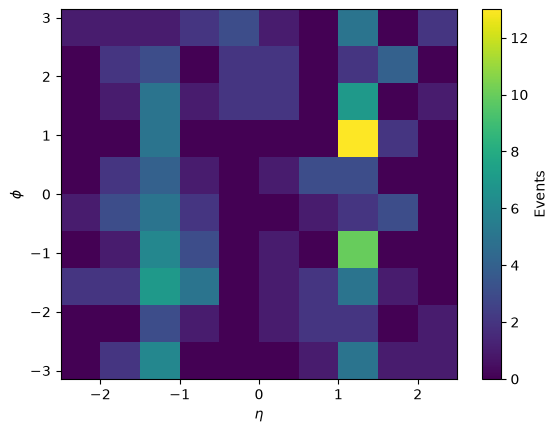

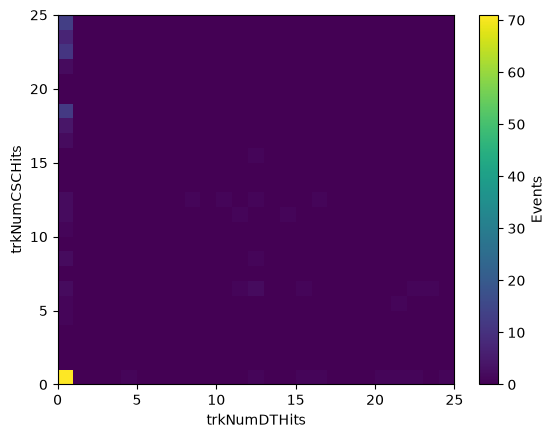

In [74]:
eta = ak.to_numpy(ak.flatten(muon_selected.eta))
phi = ak.to_numpy(ak.flatten(muon_selected.phi))

plt.hist2d(
    eta, phi,
    bins=[10, 10],
    range=[[-2.5, 2.5], [-np.pi, np.pi]]
)

plt.xlabel(r'$\eta$')
plt.ylabel(r'$\phi$')
plt.colorbar(label='Events')
plt.show()

dt = ak.to_numpy(ak.flatten(muon_selected.trkNumDTHits))
csc = ak.to_numpy(ak.flatten(muon_selected.trkNumCSCHits))

plt.hist2d(
    dt, csc,
    bins=[25, 25],
    range=[[0, 25], [0, 25]]
)

plt.xlabel(r'trkNumDTHits')
plt.ylabel(r'trkNumCSCHits')
plt.colorbar(label='Events')
plt.show()

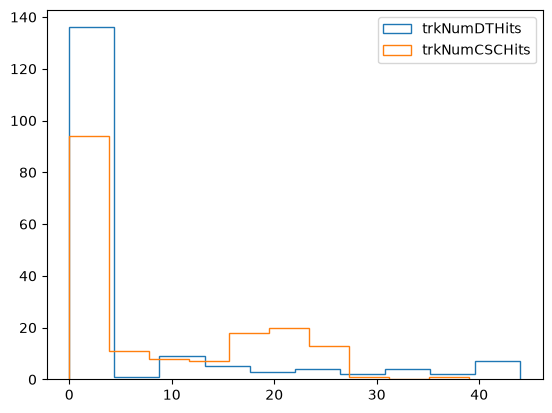


Event 0
                             pT                  eta                  phi            diMuon pt                  DTH                  CSC                   0                   -1                   -2                   -3
Reco               [46.1, 7.36]        [-1.68, 1.51]       [-2.46, -2.59]           52.240005              [0, 0]            [16, 23]
Gen                [45.9, 7.43]        [-1.68, 1.51]       [-2.46, -2.59]                 None                None                None           [13, -13]            [13, -13]            [13, -13]             [23, 23]

Event 1
                             pT                  eta                  phi            diMuon pt                  DTH                  CSC                   0                   -1
Reco               [46.4, 42.1]       [-1.71, -2.17]        [-0.38, 2.96]           71.793915              [0, 0]            [12, 21]
Gen                [46.5, 41.8]       [-1.71, -2.17]       [-0.379, 2.95]                 None    

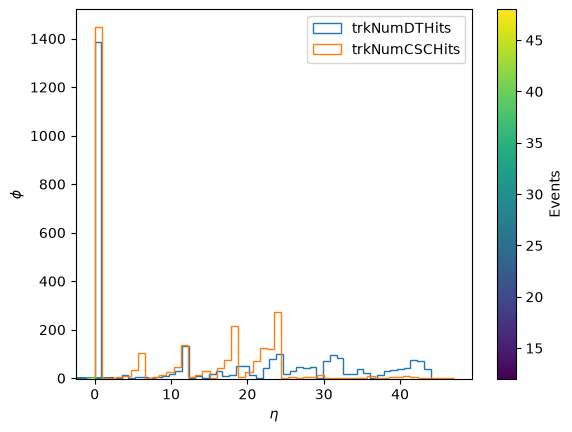

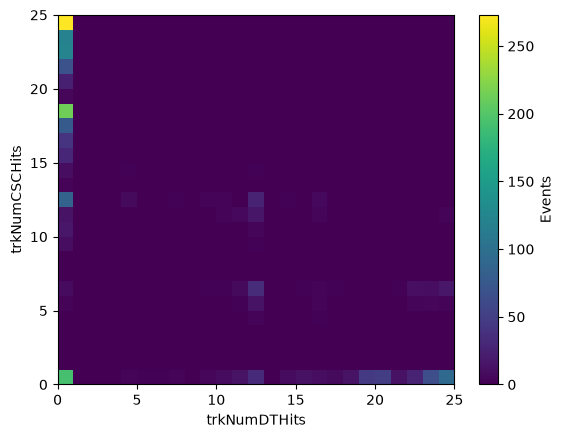

In [75]:
muon = events.Muon[
    ak.argsort(events.Muon.pt, axis=1, ascending=False)
]
has_two_muons = ak.num(muon) >= 2
events_2mu = events[has_two_muons]
muon_2mu = muon[has_two_muons]
muon0 = muon_2mu[:, 0]  # leading pT
muon1 = muon_2mu[:, 1]  # subleading pT
deltaR = muon0.delta_r(muon1)
mask = deltaR > 1
events_selected = events_2mu[mask]
muon_selected = muon_2mu[mask]

genpart = events_selected.GenPart
# genpart_idx = ak.local_index(genpart, axis=1)
gen_muon_mask = (
    (abs(genpart.pdgId) == 13) &
    (genpart.status == 1)
)

gen_muons = genpart[gen_muon_mask]
# gen_muon_indices = genpart_idx[gen_muon_mask]
sort_idx = ak.argsort(
    gen_muons.pt,
    axis=1,
    ascending=False
)

gen_muons = gen_muons[sort_idx]
# gen_muon_indices = gen_muon_indices[sort_idx]
for x in range(5):
    mother_idx = gen_muons[x].genPartIdxMother
    mother_pdgid = genpart[x].pdgId[mother_idx]

    pdg_gen = {}
    count = 0
    muons = gen_muons[x]
    muons_pdgId = [int(i.pdgId) for i in muons]
    pdg_gen[count] = muons_pdgId
    idx = [int(i) for i in muons.genPartIdxMother]
    while any(abs(pdgid) == 13 for pdgid in muons_pdgId):
        count += 1
        mother_pdgId = [
            int(genpart[x].pdgId[i])
            for i in idx
        ]
        pdg_gen[count] = mother_pdgId
        # Move to the next generation
        idx = [
            int(genpart[x].genPartIdxMother[i])
            for i in idx
            if i >= 0
        ]
        muons_pdgId = mother_pdgId
    n_gen = pdg_gen.keys()


    print(f"\nEvent {x}")
    print(f"{'':10s} {'pT':>20s} {'eta':>20s} {'phi':>20s} {'diMuon pt':>20s} {'DTH':>20s} {'CSC':>20s}"  + " ".join(f"{str(-h):>20s}" for h in n_gen))

    print(
        f"{'Reco':10s} "
        f"{str(muon_selected[x].pt):>20s} "
        f"{str(muon_selected[x].eta):>20s} "
        f"{str(muon_selected[x].phi):>20s}"
         f"{str(dimuon_pt[x]):>20s}"
         f"{str(muon_selected[x].trkNumDTHits):>20s}"
        f"{str(muon_selected[x].trkNumCSCHits):>20s}"
    )

    print(
    f"{'Gen':10s} "
    f"{str(gen_muons[x].pt):>20s} "
    f"{str(gen_muons[x].eta):>20s} "
    f"{str(gen_muons[x].phi):>20s} "
    f"{str(None):>20s}"
    f"{str(None):>20s}"
        f"{str(None):>20s}"
    + " ".join(f"{str(pdg_gen[k]):>20s}" for k in pdg_gen)
)
plt.hist(ak.to_numpy(ak.flatten(muon_selected.trkNumDTHits)), bins =50, label = "trkNumDTHits", histtype = "step")

plt.hist(ak.to_numpy(ak.flatten(muon_selected.trkNumCSCHits)), bins =50, label = "trkNumCSCHits", histtype = "step")
plt.legend()

eta = ak.to_numpy(ak.flatten(muon_selected.eta))
phi = ak.to_numpy(ak.flatten(muon_selected.phi))

plt.hist2d(
    eta, phi,
    bins=[10, 10],
    range=[[-2.5, 2.5], [-np.pi, np.pi]]
)

plt.xlabel(r'$\eta$')
plt.ylabel(r'$\phi$')
plt.colorbar(label='Events')
plt.show()

dt = ak.to_numpy(ak.flatten(muon_selected.trkNumDTHits))
csc = ak.to_numpy(ak.flatten(muon_selected.trkNumCSCHits))

plt.hist2d(
    dt, csc,
    bins=[25, 25],
    range=[[0, 25], [0, 25]]
)

plt.xlabel(r'trkNumDTHits')
plt.ylabel(r'trkNumCSCHits')
plt.colorbar(label='Events')
plt.show()